# Question 0

**We can measure the distances (i.e. cosine distance) between the known papers and unknown papers. The known papers that are closest/most similar to the unknown papers will likely be written by the same authors**

# Question 1

In [2]:
import pandas as pd
import requests
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer


nums = list(range(1,86))
papers = []


# Read in each paper as an entry in a list
for num in nums:
    url = f"https://dlsun.github.io/pods/data/federalist/{num}.txt"
    text = requests.get(url).text
    papers.append(text)

In [3]:
# Format the list as pandas series
papers = pd.Series(papers)
papers = papers.str.lower()

# Convert each paper into term-frequency vector

vec = CountVectorizer(max_features=50)

tf_df = pd.DataFrame(vec.fit_transform(papers).toarray(), columns=vec.get_feature_names_out(), index=[nums])
tf_df = tf_df.reset_index()
tf_df = tf_df.rename(columns={"level_0": "paper"})
tf_df

,paper,all,an,and,any,are,as,at,be,been,...,them,they,this,those,to,we,which,will,with,would
0,1,9,11,40,6,12,10,8,34,3,...,2,6,14,9,72,8,18,25,6,2
1,2,4,1,83,1,6,16,10,15,8,...,4,22,14,2,53,5,11,2,13,5
2,3,4,3,60,5,8,24,1,31,2,...,8,5,6,6,56,0,11,24,10,2
3,4,4,3,90,5,11,20,2,26,2,...,12,17,1,4,51,10,10,15,12,17
4,5,4,4,72,3,3,3,4,31,0,...,11,11,6,9,45,5,10,7,11,37
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80,81,13,22,88,15,15,46,7,85,22,...,16,11,44,12,163,2,41,30,14,21
81,82,7,10,41,1,11,15,2,36,1,...,4,10,14,6,83,2,18,7,6,11
82,83,28,20,121,16,43,54,19,105,36,...,21,29,60,13,219,5,79,24,30,48
83,84,14,15,89,32,33,35,10,94,18,...,5,22,36,9,140,11,53,38,14,18


# Question 2

In [4]:
# Read in known authorship csv
authorship = pd.read_csv("https://dlsun.github.io/pods/data/federalist/authorship.csv")
authorship = authorship.rename(columns={"Paper": "paper", "Author": "author"})

# Merge csv onto tf_df
tf_df = authorship.merge(tf_df, on="paper")

In [5]:
tf_df["author"] = tf_df["author"].astype("category")

In [6]:

words = tf_df.columns.drop(["paper", "author"])

# Find most common words by author
word_frequency = (
    tf_df[tf_df["author"].notna()]
    .groupby("author")[words]
    .mean()
    .reset_index()
    .melt(
        id_vars="author",
        var_name="word",
        value_name="mean_frequency"
    )
)

# Find top 5 words for each author
top_by_author = (
    word_frequency
    .sort_values("mean_frequency", ascending=False)
    .groupby("author")
    .head(5)
)

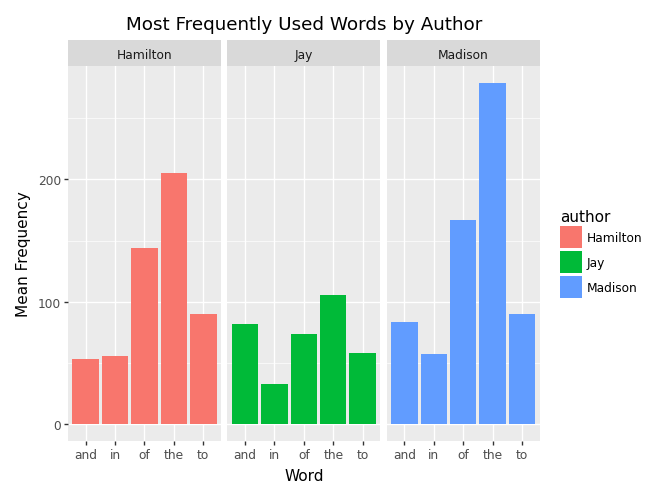

In [7]:
from plotnine import *
# Create visualizations
(
    ggplot(top_by_author, aes(x="word", y="mean_frequency", fill="author"))
    + geom_col()
    + facet_wrap("author", scales="free_x")
    + labs(
        x="Word",
        y="Mean Frequency",
        title="Most Frequently Used Words by Author"
    )
)

In [8]:
# Look at average length of paper by author to explain differences
tf_df2 = tf_df.copy()


tf_df2["paper_length"] = [len(paper.split()) for paper in papers]
tf_df2.groupby("author")["paper_length"].mean()
avg_length = (
    tf_df2[tf_df2["author"].notna()]
    .groupby("author")["paper_length"]
    .mean()
    .reset_index()
)
avg_length

,author,paper_length
0,Hamilton,2221.058824
1,Jay,1683.800000
2,Madison,2778.142857


**All 3 authors share the same top 5 most commonly used words: Be, of, to, and, in. However, the frequency of those words varies between each author. For example, Madison uses "the" over 350 times on average per paper, much higher than the second highest average frequency word between the authors, Hamilton's "the".**


**Another thing I noticed was that the top 5 words for Jay were used less on average than both Hamilton and Madison, so I decided to look at the average length of each paper by author. Madison has the highest average length (in terms of number of words) per paper, followed by Hamilton and then Jay (who comes in at more than 1000 words less than Madison on average). This likely explains why the average frequency counts seem to somewhat follow that pattern, with Madison's frequency counts being slightly higher than Hamilton's, and much higher than Jay's.**

# Question 3

**We can compare documents with known authors to the documents with unknown authors, measuring the cosine distance between them. The author with the most known documents closest to the unknown document will likely be the unknown author.**

# Question 4

In [9]:
from sklearn.metrics.pairwise import cosine_similarity
sim_tf = pd.DataFrame(cosine_similarity(tf_df[words]), index=tf_df["paper"], columns=tf_df["paper"])

known = tf_df.dropna(subset=["author"]).copy()
unknown = tf_df[tf_df["author"].isna()].copy()
tf_results = known[["paper", "author"]].copy()

predictions = []
neighbors = []

# For each unknown paper, calculate the cosine distance between the unknown paper and known papers

for paper_num in unknown["paper"]:
    tf_results["cosine_distance"] = (1 - sim_tf.loc[paper_num, known["paper"]].values)

    # Sort the results for most similar papers
    nearest_tf = tf_results.sort_values("cosine_distance").head(5)
    nearest_tf["unknown_paper"] = paper_num
    neighbors.append(nearest_tf)

    # Make author prediction based on the authors of the closest papers
    tf_prediction = nearest_tf.head(5)["author"].value_counts().idxmax()

    predictions.append({"paper": paper_num, "predicted_author": tf_prediction})

predictions_df = pd.DataFrame(predictions)
predictions_df.head()
neighbors_df = pd.concat(neighbors, ignore_index = True)

Based off of this prediction I would attribute the following papers to each of the following authors:

**Madison:** 18, 19, 20, 50, 51, 53, 54, 57, 58, 63

**Hamilton:** 49, 52, 55, 56, 62

**Jay:** None

# Question 5

In [10]:
results = []

for paper_num in known["paper"]:

    tf_results = known[["paper", "author"]].copy()

    tf_results["cosine_distance"] = (
        1 - sim_tf.loc[paper_num, known["paper"]].values
    )

    # remove the paper itself
    tf_results = tf_results[tf_results["paper"] != paper_num]

    # get 5 closest known papers
    nearest_tf = (
        tf_results
        .sort_values("cosine_distance")
        .head(5)
    )

    # majority vote
    predicted_author = (
        nearest_tf["author"]
        .value_counts()
        .idxmax()
    )

    actual_author = (
        known.loc[known["paper"] == paper_num, "author"]
        .iloc[0]
    )

    correct = (predicted_author == actual_author)

    results.append({
        "paper": paper_num,
        "actual_author": actual_author,
        "predicted_author": predicted_author,
        "correct_prediction": correct
    })

known_predictions = pd.DataFrame(results)

known_predictions

,paper,actual_author,predicted_author,correct_prediction
0,1,Hamilton,Hamilton,True
1,2,Jay,Madison,False
2,3,Jay,Jay,True
3,4,Jay,Jay,True
4,5,Jay,Jay,True
...,...,...,...,...
65,81,Hamilton,Hamilton,True
66,82,Hamilton,Hamilton,True
67,83,Hamilton,Hamilton,True
68,84,Hamilton,Hamilton,True


In [11]:
# Find proportion of predictions that were correct for known papers
known_predictions["correct_prediction"].mean()

np.float64(0.9571428571428572)

**The algorithm appears to work fairly well, having a roughly 96% accuracy among known papers**

# Question 6

In [12]:
known_predictions.groupby("actual_author")["correct_prediction"].mean()

actual_author
Hamilton    1.000000
Jay         0.600000
Madison     0.928571
Name: correct_prediction, dtype: float64

**The algorithm clearly worked perfectly for papers written by Hamilton, fairly well for papers written by Madison, and not so great for papers written by Jay. If there were more papers written by Jay, I would be interested in seeing whether that changes not only the proportion of correctly predicted documents for him, but also for Hamilton and Madison.**

# Question 7

In [13]:
known_predictions.groupby("predicted_author")["correct_prediction"].mean()

predicted_author
Hamilton    0.980769
Jay         1.000000
Madison     0.866667
Name: correct_prediction, dtype: float64

**The results are definitely different when grouping by `actual_author` vs. `predicted_author`. The algorithm still seems to have worked well for Hamilton, less so for Madison, and all the documents that were predicted to be written by Jay were actually written by him. Once again I wonder if this would change if more documents were written by Jay.**